# 🧠 BraTS-Africa Dataset Exploration & Medical Imaging Primer
### **Semi-Supervised Brain Tumor Segmentation Using Medical Foundation Models Under Limited Annotation**

Welcome to the exploratory data analysis and technical primer for the **BraTS-Africa (Sub-Saharan Africa - SSA)** dataset.

---

### 🎯 Key Objectives of this Notebook
1. **Understand Medical Imaging File Formats:** Demystify `.nii.gz` (NIfTI format) and how 3D medical volumes differ from 2D images.
2. **Deconstruct Multi-Parametric MRI (mpMRI):** Learn why 4 distinct sequences (`t1n`, `t1c`, `t2w`, `t2f`) are required for neuro-oncology.
3. **Analyze Ground Truth Segmentation Labels:** Understand the 3 tumor sub-compartments:
   - **NCR:** Necrotic Core
   - **ED:** Peritumoral Edematous / Infiltrated Tissue
   - **ET:** Enhancing Tumor
   - Standard clinical sub-regions: **Whole Tumor (WT)**, **Tumor Core (TC)**, and **Enhancing Tumor (ET)**.
4. **Interactive 2D & 3D Visualizations:**
   - Multi-modal slice viewer with semi-transparent color mask overlays.
   - Tri-planar orthogonal views (Axial, Coronal, Sagittal) centered on tumor centroids.
5. **Preprocessing & Intensity Normalization:** Non-zero brain masking, percentile clipping, and z-score normalization.
6. **Foundation Model Interfacing:** Extracting 2D slices and generating prompt bounding boxes / point coordinates for **SAM**, **MedSAM**, and **SAM-Med2D**.


In [1]:
# 1. Essential Imports
import os
import sys
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nibabel as nib

# Add repository root to Python path
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print(f"Working Directory : {os.getcwd()}")
print(f"Repository Root   : {repo_root}")
print(f"NumPy Version     : {np.__version__}")
print(f"NiBabel Version   : {nib.__version__}")

Working Directory : d:\MAIN DATA\Documents\MBC\Segmentation Paper\notebooks
Repository Root   : d:\MAIN DATA\Documents\MBC\Segmentation Paper
NumPy Version     : 2.0.2
NiBabel Version   : 5.3.2


---
## 📦 1. Demystifying the Dataset: What is a `.nii.gz` File?

### 🔬 What does NIfTI stand for?
**NIfTI** stands for **Neuroimaging Informatics Technology Initiative**. It is the standard file format across computational neuroscience and medical image computing.

### ❓ How does a 3D NIfTI file differ from standard 2D images (JPEG / PNG)?
| Characteristic | Standard 2D Image (`.jpg`, `.png`) | 3D Medical Scan (`.nii` / `.nii.gz`) |
| :--- | :--- | :--- |
| **Data Structure** | 2D pixel grid $(H 	imes W)$ with 1 or 3 channels (RGB) | **3D voxel grid** $(X 	imes Y 	imes Z)$ representing real physical anatomy |
| **Pixel vs. Voxel** | Pixel = 2D picture element without physical scale | **Voxel** = 3D volume element with physical dimensions (e.g. $1.0 \times 1.0 \times 1.0\text{ mm}^3$) |
| **Spatial Coordinates** | Screen coordinates (row, col) | **Affine Matrix ($4 \times 4$)** mapping voxel indices $(i, j, k)$ to millimeters in patient space (RAS+) |
| **Bit Depth** | Typically 8-bit unsigned integer ($0 - 255$) | 16-bit, 32-bit, or 64-bit float/int (continuous magnetic resonance signal intensity) |
| **Compression** | `.jpg`, `.png` | `.nii.gz` is standard Gzip compression of the uncompressed `.nii` binary stream |


In [2]:
# 2. Inspecting the BraTS-Africa Cohort Directory Structure
data_dir = os.path.join(repo_root, 'data', 'BraTS-Africa')

cohorts = ['95_Glioma', '51_OtherNeoplasms']
patient_inventory = []

for cohort in cohorts:
    cohort_path = os.path.join(data_dir, cohort)
    if not os.path.exists(cohort_path):
        continue
    patients = sorted([f for f in os.listdir(cohort_path) if f.startswith('BraTS-SSA')])
    for pid in patients:
        p_path = os.path.join(cohort_path, pid)
        files = os.listdir(p_path)
        patient_inventory.append({
            'cohort': cohort,
            'patient_id': pid,
            'folder_path': p_path,
            'num_files': len(files),
            'has_seg': any(f.endswith('-seg.nii.gz') for f in files),
            'has_t1c': any(f.endswith('-t1c.nii.gz') for f in files),
            'has_t1n': any(f.endswith('-t1n.nii.gz') for f in files),
            'has_t2f': any(f.endswith('-t2f.nii.gz') for f in files),
            'has_t2w': any(f.endswith('-t2w.nii.gz') for f in files),
        })

df_inventory = pd.DataFrame(patient_inventory)
print(f"Total Patient Cases Discovered: {len(df_inventory)}")
print("Cohort Breakdown:")
print(df_inventory["cohort"].value_counts())
display(df_inventory.head())

Total Patient Cases Discovered: 146
Cohort Breakdown:
cohort
95_Glioma            95
51_OtherNeoplasms    51
Name: count, dtype: int64


,cohort,patient_id,folder_path,num_files,has_seg,has_t1c,has_t1n,has_t2f,has_t2w
0,95_Glioma,BraTS-SSA-00002-000,d:\MAIN DATA\Documents\MBC\Segmentation Paper\...,5,True,True,True,True,True
1,95_Glioma,BraTS-SSA-00007-000,d:\MAIN DATA\Documents\MBC\Segmentation Paper\...,5,True,True,True,True,True
2,95_Glioma,BraTS-SSA-00008-000,d:\MAIN DATA\Documents\MBC\Segmentation Paper\...,5,True,True,True,True,True
3,95_Glioma,BraTS-SSA-00010-000,d:\MAIN DATA\Documents\MBC\Segmentation Paper\...,5,True,True,True,True,True
4,95_Glioma,BraTS-SSA-00011-000,d:\MAIN DATA\Documents\MBC\Segmentation Paper\...,5,True,True,True,True,True


---
## 🩻 2. Understanding the 4 Multi-Parametric MRI Sequences

Gliomas and intracranial neoplasms are heterogeneous and structurally complex. A single MRI sequence cannot capture all pathological features. BraTS provides four coregistered scans per patient:

1. **`t1n` (T1-Weighted Native / Pre-Contrast):**
   - High spatial resolution of native brain parenchyma.
   - White matter is bright, gray matter is intermediate, CSF is dark.
   - Useful for delineating anatomical boundaries.
2. **`t1c` (T1-Weighted Contrast-Enhanced / T1-Gd):**
   - Injected with intravenous **Gadolinium contrast agent**.
   - Highlights areas where the **Blood-Brain Barrier (BBB)** has broken down due to neo-angiogenesis.
   - Actively proliferating, hyper-vascularized tumor borders glow brightly.
3. **`t2w` (T2-Weighted):**
   - Water and fluids appear hyperintense (bright); fat and solid bone appear dark.
   - Excellent for detecting vasogenic edema and cystic cavities.
4. **`t2f` (T2-FLAIR / Fluid Attenuated Inversion Recovery):**
   - T2 sequence engineered with an inversion pulse that **nulls the free fluid signal of Cerebrospinal Fluid (CSF)** in the ventricles.
   - Because normal CSF is blacked out, peritumoral infiltrative edema and hyperintense tumor margins stand out starkly.


In [3]:
# 3. Deep Inspection of a Single Patient Case
sample_patient = df_inventory.iloc[0]
sample_dir = sample_patient['folder_path']
sample_id = sample_patient['patient_id']

print(f"Inspecting Patient: {sample_id} ({sample_patient['cohort']})")

modalities = {
    't1n': f"{sample_id}-t1n.nii.gz",
    't1c': f"{sample_id}-t1c.nii.gz",
    't2w': f"{sample_id}-t2w.nii.gz",
    't2f': f"{sample_id}-t2f.nii.gz",
    'seg': f"{sample_id}-seg.nii.gz",
}

volume_data = {}
volume_headers = {}

for m_key, fname in modalities.items():
    fpath = os.path.join(sample_dir, fname)
    nii = nib.load(fpath)
    volume_data[m_key] = nii.get_fdata()
    volume_headers[m_key] = nii.header
    
    data = volume_data[m_key]
    print(f"Modality: {m_key:4} | Shape: {str(data.shape):16} | Dtype: {str(data.dtype):10} | Range: [{data.min():7.1f}, {data.max():7.1f}] | Voxel Spacing: {nii.header.get_zooms()} mm")

Inspecting Patient: BraTS-SSA-00002-000 (95_Glioma)
Modality: t1n  | Shape: (240, 240, 155)  | Dtype: float64    | Range: [ -290.0, 11148.0] | Voxel Spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Modality: t1c  | Shape: (240, 240, 155)  | Dtype: float64    | Range: [ -473.0, 10386.0] | Voxel Spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Modality: t2w  | Shape: (240, 240, 155)  | Dtype: float64    | Range: [ -427.0, 13832.0] | Voxel Spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Modality: t2f  | Shape: (240, 240, 155)  | Dtype: float64    | Range: [ -881.0, 12000.0] | Voxel Spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Modality: seg  | Shape: (240, 240, 155)  | Dtype: float64    | Range: [    0.0,     3.0] | Voxel Spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm


---
## 🏷️ 3. Segmentation Ground Truth (`seg.nii.gz`) & BraTS Sub-Regions

The ground-truth segmentation is a multi-class integer volume where each voxel belongs to one of four classes:

| Voxel Value | Annotation Class | Clinical Definition |
| :---: | :--- | :--- |
| **0** | **Background / Healthy Tissue** | Normal brain matter, skull-stripped air background |
| **1** | **NCR (Necrotic Tumor Core)** | Dead, non-enhancing avascular necrotic debris inside tumor core |
| **2** | **ED (Peritumoral Edema)** | Infiltrating edema and swelling surrounding the active tumor |
| **3** | **ET (Enhancing Tumor)** | Actively proliferating, vascularized tumor tissue |

### 🎯 Clinical Evaluation Sub-Regions
In academic challenges and clinical studies, evaluation is performed on composite sub-regions:
- **Whole Tumor (WT):** Labels `1 + 2 + 3` (Entire pathological lesion).
- **Tumor Core (TC):** Labels `1 + 3` (Solid resectable tumor core).
- **Enhancing Tumor (ET):** Label `3` (Active neoplastic core).


In [4]:
# 4. Analyze Tumor Sub-Compartment Voxel Counts
seg = volume_data['seg']
unique_labels, label_counts = np.unique(seg, return_counts=True)

label_names = {
    0: '0 - Background',
    1: '1 - Necrotic Core (NCR)',
    2: '2 - Peritumoral Edema (ED)',
    3: '3 - Enhancing Tumor (ET)'
}

stats = []
voxel_vol_mm3 = 1.0 # Standard 1x1x1 mm^3 resolution in BraTS
for val, count in zip(unique_labels, label_counts):
    vol_cm3 = (count * voxel_vol_mm3) / 1000.0 # Convert mm^3 to cm^3 (mL)
    stats.append({
        'Label': int(val),
        'Structure': label_names.get(int(val), 'Unknown'),
        'Voxel Count': count,
        'Volume (cm³ / mL)': round(vol_cm3, 2),
        'Volume Fraction (%)': round((count / seg.size) * 100, 3)
    })

df_tumor_stats = pd.DataFrame(stats)
display(df_tumor_stats)

# Find optimal axial slice containing maximum tumor area
tumor_slice_areas = [(seg[:, :, z] > 0).sum() for z in range(seg.shape[2])]
best_axial_slice = int(np.argmax(tumor_slice_areas))
print(f"Axial slice with maximum tumor burden: Slice {best_axial_slice} ({tumor_slice_areas[best_axial_slice]} tumor voxels)")

,Label,Structure,Voxel Count,Volume (cm³ / mL),Volume Fraction (%)
0,0,0 - Background,8709539,8709.54,97.553
1,1,1 - Necrotic Core (NCR),6603,6.60,0.074
2,2,2 - Peritumoral Edema (ED),190334,190.33,2.132
3,3,3 - Enhancing Tumor (ET),21524,21.52,0.241


Axial slice with maximum tumor burden: Slice 92 (3771 tumor voxels)


---
## 🎨 4. Multi-Modal Slice Inspection with Color-Coded Masks

Let's visualize the 4 MRI sequences side-by-side at the tumor center.
We will overlay the segmentation labels using custom alpha transparency:
- 🔴 **Red:** Necrotic Core (NCR - Label 1)
- 🟢 **Green:** Peritumoral Edema (ED - Label 2)
- 🟡 **Yellow:** Enhancing Tumor (ET - Label 3)


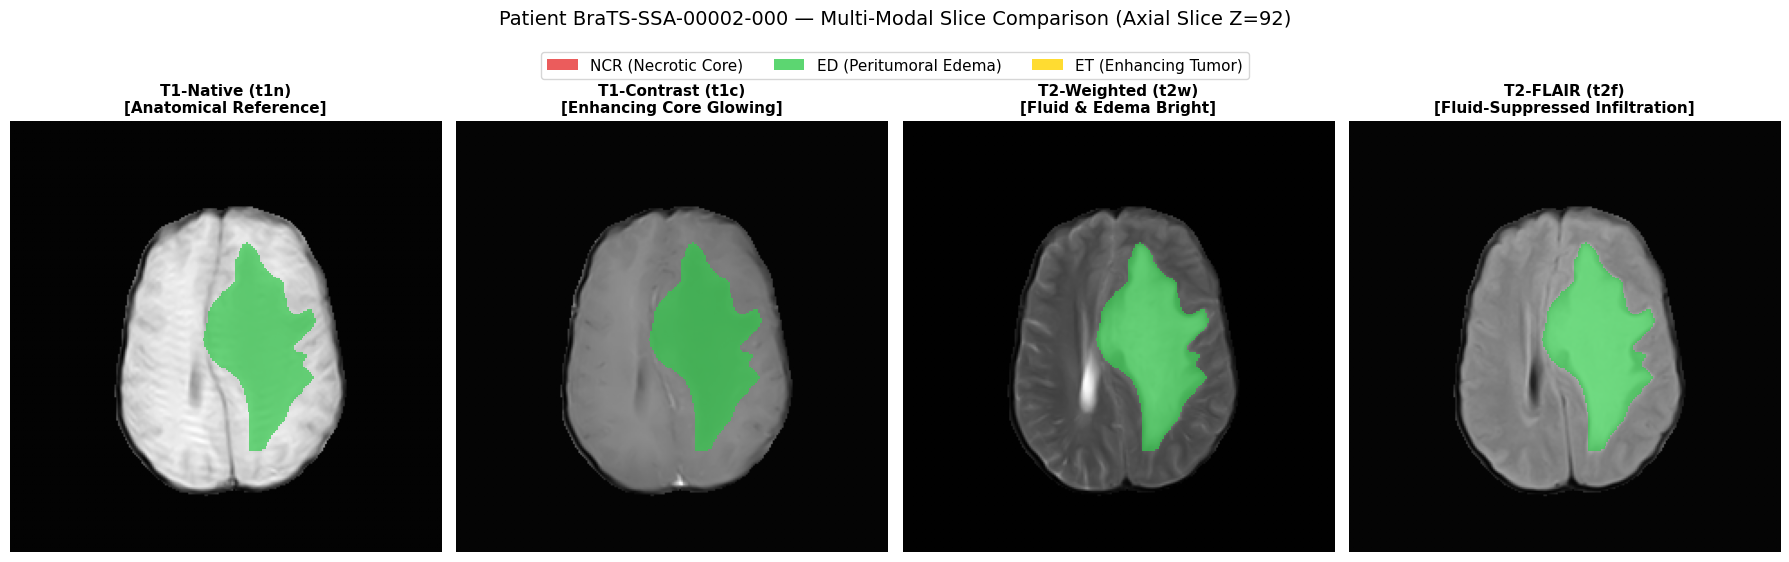

In [5]:
# 5. Side-by-Side Multi-Modal Slice Visualization
from src.utils.visualization import get_brats_colormap

cmap_brats = get_brats_colormap()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
seq_keys = ['t1n', 't1c', 't2w', 't2f']
seq_titles = [
    'T1-Native (t1n)\n[Anatomical Reference]',
    'T1-Contrast (t1c)\n[Enhancing Core Glowing]',
    'T2-Weighted (t2w)\n[Fluid & Edema Bright]',
    'T2-FLAIR (t2f)\n[Fluid-Suppressed Infiltration]'
]

for idx, (m_key, title) in enumerate(zip(seq_keys, seq_titles)):
    ax = axes[idx]
    slice_img = volume_data[m_key][:, :, best_axial_slice]
    mask_slice = seg[:, :, best_axial_slice]
    
    # Show grayscale MRI slice
    ax.imshow(slice_img.T, cmap='gray', origin='lower')
    
    # Overlay colored segmentation mask with transparency
    ax.imshow(mask_slice.T, cmap=cmap_brats, origin='lower', vmin=0, vmax=3, interpolation='nearest')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

# Legend elements
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=(0.9, 0.2, 0.2, 0.8), label='NCR (Necrotic Core)'),
    Patch(facecolor=(0.2, 0.8, 0.3, 0.8), label='ED (Peritumoral Edema)'),
    Patch(facecolor=(1.0, 0.85, 0.1, 0.9), label='ET (Enhancing Tumor)'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=11)
plt.suptitle(f"Patient {sample_id} — Multi-Modal Slice Comparison (Axial Slice Z={best_axial_slice})", fontsize=14, y=1.12)
plt.tight_layout()
plt.show()

---
## 📐 5. Tri-Planar Orthogonal Projections (Axial, Coronal, Sagittal)

Since MRI is a 3D volumetric acquisition, physicians and neurosurgeons inspect scans along all three anatomical axes:
- **Axial (Transverse) Plane ($Z$):** Cross-section looking from feet to head.
- **Coronal (Frontal) Plane ($Y$):** Cross-section looking from front of face to back of head.
- **Sagittal (Lateral) Plane ($X$):** Cross-section looking from ear to ear.


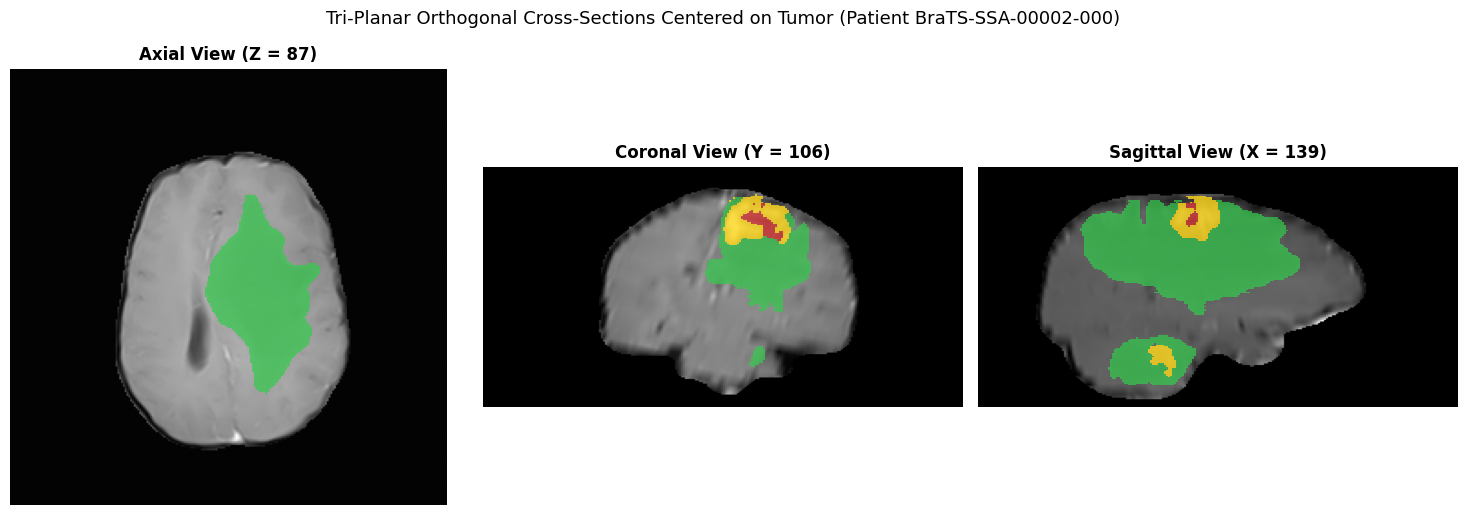

In [6]:
# 6. Tri-Planar Visualization Centered on Tumor
from src.utils.visualization import plot_triplanar_view

# Use T1-Contrast or FLAIR as the anatomical backdrop
vol_backdrop = volume_data['t1c']
coords = np.argwhere(seg > 0)
center_voxel = coords.mean(axis=0).astype(int)

fig = plot_triplanar_view(
    volume=vol_backdrop,
    seg_mask=seg,
    center_coords=(center_voxel[0], center_voxel[1], center_voxel[2]),
    title=f"Tri-Planar Orthogonal Cross-Sections Centered on Tumor (Patient {sample_id})"
)
plt.show()

---
## ⚖️ 6. Intensity Distributions & Preprocessing Pipeline

Raw MRI voxel intensities are **not standardized**:
- Unlike CT scans (which use standardized Hounsfield Units where air = -1000 HU, water = 0 HU, bone = +1000 HU), MRI intensities have **arbitrary relative units** determined by magnetic field strength, coil sensitivity, and scanner gain.
- **Solution:** 
  1. Extract non-zero brain mask (exclude air voxels).
  2. Clip outlier intensities ($0.5\%$ to $99.5\%$ percentiles).
  3. Apply **Z-score normalization**: $I_{\text{norm}} = \frac{I - \mu}{\sigma}$.


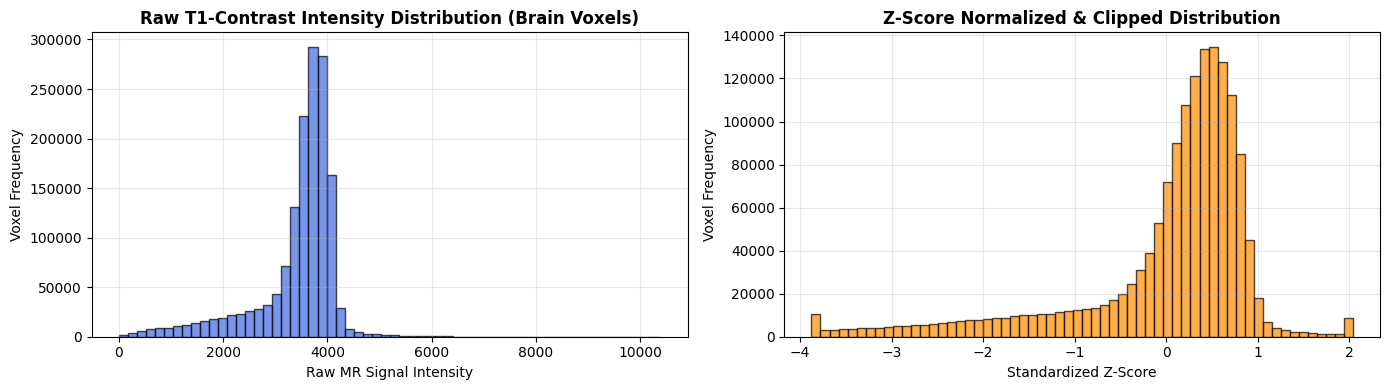

In [7]:
# 7. Intensity Distribution Before and After Normalization
from src.data.brats_dataset import BraTSDataset

raw_t1c = volume_data['t1c']
norm_t1c = BraTSDataset.normalize_intensity(raw_t1c.copy())

# Mask brain region (non-zero voxels)
brain_mask = raw_t1c > 0
raw_intensities = raw_t1c[brain_mask]
norm_intensities = norm_t1c[brain_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(raw_intensities, bins=60, color='royalblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Raw T1-Contrast Intensity Distribution (Brain Voxels)", fontweight='bold')
axes[0].set_xlabel("Raw MR Signal Intensity")
axes[0].set_ylabel("Voxel Frequency")
axes[0].grid(True, alpha=0.3)

axes[1].hist(norm_intensities, bins=60, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_title("Z-Score Normalized & Clipped Distribution", fontweight='bold')
axes[1].set_xlabel("Standardized Z-Score")
axes[1].set_ylabel("Voxel Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🤖 7. Interfacing with Medical Foundation Models (SAM / MedSAM)

How do 2D Foundation Models (like **Segment Anything Model (SAM)** or **MedSAM**) process 3D multi-parametric MRI?

1. **Slice Extraction:** Extract 2D axial slices containing suspected pathology.
2. **Channel Projection / Early Fusion:** Map the 4 MRI sequences (`t1n`, `t1c`, `t2w`, `t2f`) into 3 input channels expected by the Vision Transformer (ViT) image encoder.
3. **Prompt Conditioning:** Foundation models require prompts (e.g., bounding boxes or positive/negative point clicks). In limited-annotation research:
   - A human radiologist only draws a loose bounding box around the lesion.
   - The Foundation Model computes high-resolution mask predictions.
   - **Semi-supervised learning** uses these prompts to guide unlabeled or weakly-labeled slices.


Generated Foundation Model Bounding Box Prompt: [x_min, y_min, x_max, y_max] = [ 48.  99. 176. 169.]


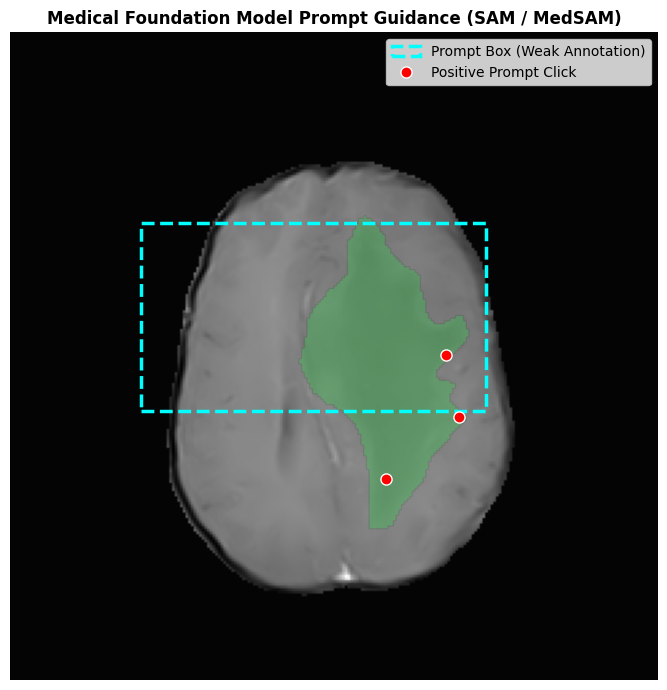

In [8]:
# 8. Simulating Bounding Box & Point Prompts for SAM / MedSAM
from src.data.transforms import FoundationModelPromptGenerator
import matplotlib.patches as patches

prompt_gen = FoundationModelPromptGenerator(perturbation_range=8)
slice_mask_2d = seg[:, :, best_axial_slice]
bbox = prompt_gen.get_bounding_box_prompt(slice_mask_2d)

print(f"Generated Foundation Model Bounding Box Prompt: [x_min, y_min, x_max, y_max] = {bbox}")

# Simulate 3 prompt clicks inside tumor
tumor_pixels = np.argwhere(slice_mask_2d > 0)
sampled_clicks = tumor_pixels[np.random.choice(len(tumor_pixels), size=3, replace=False)]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(volume_data['t1c'][:, :, best_axial_slice].T, cmap='gray', origin='lower')
ax.imshow(slice_mask_2d.T, cmap=cmap_brats, origin='lower', alpha=0.5, vmin=0, vmax=3)

# Draw Bounding Box Prompt
if bbox is not None:
    x_min, y_min, x_max, y_max = bbox
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2.5, edgecolor='cyan', facecolor='none', linestyle='--', label='Prompt Box (Weak Annotation)'
    )
    ax.add_patch(rect)

# Draw Point Prompts
for pt in sampled_clicks:
    ax.plot(pt[0], pt[1], 'ro', markersize=8, markeredgecolor='white', label='Positive Prompt Click')

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=10)

ax.set_title("Medical Foundation Model Prompt Guidance (SAM / MedSAM)", fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 🏁 8. Next Steps: Semi-Supervised Model Training

Now that you understand the dataset:
1. Verify the dataset splits generated in `data/splits.json`:
   - 102 Train patients (with 10%, 20%, 50%, 100% labeled partitions).
   - 22 Validation patients.
   - 22 Test patients.
2. Launch the semi-supervised **Mean Teacher** training pipeline:
   ```bash
   python scripts/train_semi_supervised.py --config configs/default_config.yaml --ratio ratio_10
   ```
3. Evaluate model predictions across **Whole Tumor (WT)**, **Tumor Core (TC)**, and **Enhancing Tumor (ET)** using:
   ```bash
   python scripts/evaluate_metrics.py
   ```
